# Natural Language to SQL with CodeT5+
This notebook implements a text-to-SQL model using Google's `flan T5-base`, trained amd evaluated on `b-mc2/sql-create-context`

In [2]:
!pip install -q transformers datasets accelerate tensorboard

In [3]:
!pip install -q sentencepiece protobuf evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


In [4]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from datasets import load_dataset
import torch


In [5]:
# 1. Load Datasets
# 'sql-create-context' is excellent for teaching the model DDL-to-SQL mapping
train_dataset = load_dataset('b-mc2/sql-create-context', split='train')

# 'spider' is the academic gold standard for zero-shot cross-domain evaluation
spider_val = load_dataset('richardr1126/spider-context-validation', split='validation')

print(f'Train set size: {len(train_dataset)}')
print(f'Spider Validation set size: {len(spider_val)}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sql_create_context_v4.json:   0%|          | 0.00/21.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/78577 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

validation_sql.json: 0.00B [00:00, ?B/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Train set size: 78577
Spider Validation set size: 1034


# Load Model

In [6]:
from google.colab import userdata

# Get token
try:
    hf_token = userdata.get('HF_TOKEN')
except:
    hf_token = None

# Load Model and Tokenizer
model_id = 'google/flan-t5-base'

# Define the single device you want to use
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    use_fast=False,
    extra_special_tokens=[]
)

model = AutoModelForSeq2SeqLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    # REMOVE: device_map='auto'
    # ADD: trust_remote_code and tie_word_embeddings for safety
    trust_remote_code=True,
    tie_word_embeddings=False
)

# Explicitly move the model to your chosen device
model.to(device)

print(f'Model loaded and successfully pinned to: {device}')

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

T5ForConditionalGeneration LOAD REPORT from: google/flan-t5-base
Key                         | Status  | 
----------------------------+---------+-
encoder.embed_tokens.weight | MISSING | 
decoder.embed_tokens.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded and successfully pinned to: cuda


In [7]:
# Preview the training data format
display(train_dataset.to_pandas().head())

,answer,question,context
0,SELECT COUNT(*) FROM head WHERE age > 56,How many heads of the departments are older th...,CREATE TABLE head (age INTEGER)
1,"SELECT name, born_state, age FROM head ORDER B...","List the name, born state and age of the heads...","CREATE TABLE head (name VARCHAR, born_state VA..."
2,"SELECT creation, name, budget_in_billions FROM...","List the creation year, name and budget of eac...","CREATE TABLE department (creation VARCHAR, nam..."
3,"SELECT MAX(budget_in_billions), MIN(budget_in_...",What are the maximum and minimum budget of the...,CREATE TABLE department (budget_in_billions IN...
4,SELECT AVG(num_employees) FROM department WHER...,What is the average number of employees of the...,CREATE TABLE department (num_employees INTEGER...


### 3. Evaluation Metrics & Visualizations
We will define metrics to track during training and visualize our dataset characteristics.

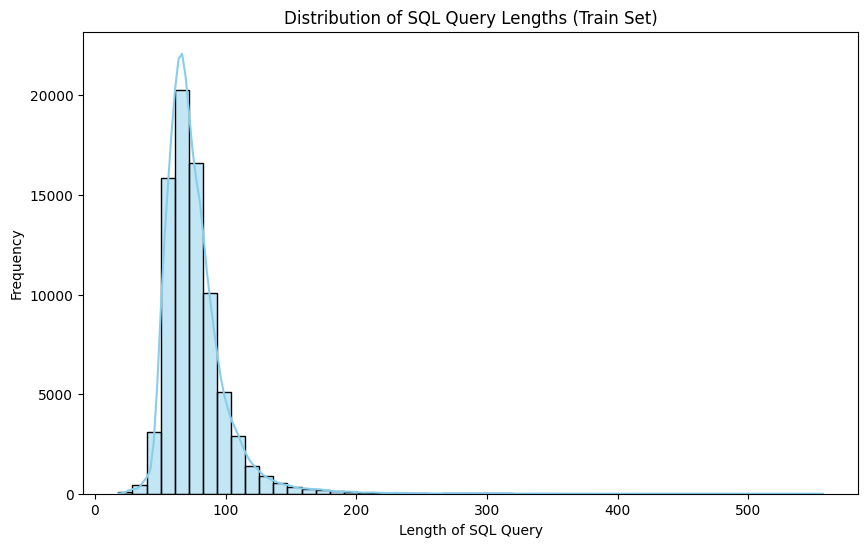

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Visualize query length distribution
train_df = train_dataset.to_pandas()
train_df['query_length'] = train_df['answer'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(train_df['query_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of SQL Query Lengths (Train Set)')
plt.xlabel('Length of SQL Query')
plt.ylabel('Frequency')
plt.show()

In [9]:
import numpy as np
import evaluate # The modern replacement for datasets.load_metric

# 1. Load the Exact Match metric from the new library
# In a research context, you might also load "rouge" or "bleu",
# but for SQL, Exact Match is the standard starting point.
em_metric = evaluate.load("exact_match")

def compute_metrics(eval_preds):
    preds, labels = eval_preds

    # If the model returns logits, we take the argmax to get token IDs
    if isinstance(preds, tuple):
        preds = preds[0]

    # Convert token IDs back to strings
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    # Replace -100 (ignore index) in labels so the tokenizer can decode them
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # 2. Clean whitespace for a fair comparison
    # Group Project Tip: Students often forget that "SELECT *" and "SELECT  *"
    # are technically different strings but the same SQL. .strip() helps.
    decoded_preds = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    # 3. Compute using the evaluate library
    results = em_metric.compute(predictions=decoded_preds, references=decoded_labels)

    return {"exact_match": results["exact_match"]}

print("Metric function defined using 'evaluate' library successfully.")

Metric function defined using 'evaluate' library successfully.


### 4. PyTorch Dataset and Training Setup
We will define custom Dataset classes to handle tokenization and mapping of the text-to-SQL pairs.

In [10]:
from torch.utils.data import Dataset, DataLoader

class SQLDataset(Dataset):
    def __init__(self, dataset, tokenizer, max_length=512):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[int(idx)] # Cast idx to int
        # Input: "question: {q} context: {c}"
        input_text = f"question: {item['question']} context: {item['context']}"
        target_text = item['answer']

        inputs = self.tokenizer(input_text, max_length=self.max_length, padding='max_length', truncation=True, return_tensors='pt')
        targets = self.tokenizer(target_text, max_length=self.max_length, padding='max_length', truncation=True, return_tensors='pt')

        labels = targets.input_ids
        labels[labels == self.tokenizer.pad_token_id] = -100 # Mask padding for loss

        return {
            'input_ids': inputs.input_ids.squeeze(),
            'attention_mask': inputs.attention_mask.squeeze(),
            'labels': labels.squeeze()
        }

# Initialize PyTorch Datasets
train_pt_dataset = SQLDataset(train_dataset, tokenizer)
train_loader = DataLoader(train_pt_dataset, batch_size=8, shuffle=True)

Dataset class for the spider test dataset



In [11]:
from datasets import load_dataset
from torch.utils.data import DataLoader

# 1. Load the Spider validation set that is already formatted with 'context'
# This matches the schema-aware training you did with sql-create-context
spider_test_raw = load_dataset("richardr1126/spider-context-validation", split="validation")

# 2. Wrap it in your existing SQLDataset class
# (Make sure your class handles 'question', 'context', and 'query'/'answer' columns)
class SpiderTestDataset(Dataset):
    def __init__(self, dataset, tokenizer, max_length=512):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[int(idx)] # Cast idx to int
        # Spider-context uses 'query' instead of 'answer', so we check for both
        target_text = item.get('answer') or item.get('query')
        input_text = f"question: {item['question']} context: {item['context']}"

        inputs = self.tokenizer(input_text, max_length=self.max_length, padding='max_length', truncation=True, return_tensors='pt')
        targets = self.tokenizer(target_text, max_length=self.max_length, padding='max_length', truncation=True, return_tensors='pt')

        labels = targets.input_ids
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids': inputs.input_ids.squeeze(),
            'attention_mask': inputs.attention_mask.squeeze(),
            'labels': labels.squeeze()
        }

spider_test_dataset = SpiderTestDataset(spider_test_raw, tokenizer)
spider_test_loader = DataLoader(spider_test_dataset, batch_size=8, shuffle=False)

print(f"Spider Validation Set ready: {len(spider_test_dataset)} samples.")

Spider Validation Set ready: 1034 samples.


In [12]:
from torch.optim import AdamW
from tqdm.auto import tqdm

# Standard PyTorch Training Loop Setup
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
optimizer = AdamW(model.parameters(), lr=5e-5)

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc='Training'):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)

print("PyTorch training environment ready.")

PyTorch training environment ready.


# Execute Training and Spider Evaluation

Run the cells below to start the fine-tuning. It includes a basic "Early Saving" logic to keep your best-performing version.

In [13]:
from torch.utils.data import Subset
import numpy as np

# Select 10,000 random indices from your 78k training set
subset_indices = np.random.choice(len(train_pt_dataset), 20000, replace=False)
subset_train_dataset = Subset(train_pt_dataset, subset_indices)

# New loader with the subset (keeping batch_size=2 for VRAM safety)
train_loader = DataLoader(subset_train_dataset, batch_size=2, shuffle=True)

print(f"Dataset capped at 20,000 samples.")

Dataset capped at 20,000 samples.


In [14]:
import torch
import os
import gc
import warnings
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, Adafactor, logging
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# 1. KILL BACKGROUND ERRORS & HUB SYNC
os.environ["TRANSFORMERS_NO_AD_HOC_KHF_TRANSFORMS"] = "1"
# logging.set_verbosity_error() silences the "ReadTimeout" and "AttributeError" spam
logging.set_verbosity_error()
warnings.filterwarnings("ignore")

# 2. EMERGENCY CLEANUP
if 'model' in globals(): del model
if 'optimizer' in globals(): del optimizer
gc.collect()
torch.cuda.empty_cache()

# 3. SETUP & LOAD
device = torch.device('cuda:0')
model_id = 'google/flan-t5-base'

print(f"Loading {model_id} (Quiet Mode)...")

tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=False, extra_special_tokens=[])
model = AutoModelForSeq2SeqLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    tie_word_embeddings=False,
    trust_remote_code=True
).to(device)

# 4. OPTIMIZATIONS
model.config.use_cache = False
model.gradient_checkpointing_enable()

# 5. ADAFACTOR OPTIMIZER (The VRAM Saver)
optimizer = Adafactor(
    model.parameters(),
    lr=5e-5,
    scale_parameter=False,
    relative_step=False,
    warmup_init=False
)

# 6. DATA & LOOP SETUP (Capped at 20k rows)
train_loader = DataLoader(subset_train_dataset, batch_size=2, shuffle=True)
spider_test_loader = DataLoader(spider_test_dataset, batch_size=2, shuffle=False)
accumulation_steps = 8
MAX_STEPS = 5000 # Reduced MAX_STEPS for faster training

print(f"Starting stabilized training on {device}...")

for epoch in range(1):
    model.train()
    total_loss = 0
    optimizer.zero_grad()

    train_bar = tqdm(train_loader, desc=f"Training")
    for i, batch in enumerate(train_bar):
        if i >= MAX_STEPS: break

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss / accumulation_steps
        loss.backward()

        if (i + 1) % accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

        total_loss += loss.item() * accumulation_steps
        train_bar.set_postfix(loss=loss.item() * accumulation_steps)

    # --- EVALUATION ---
#     model.eval()
#     all_preds, all_labels = [], []
#     with torch.no_grad():
#         for batch in tqdm(spider_test_loader, desc=f"Spider Eval"):
#             input_ids = batch['input_ids'].to(device)
#             attention_mask = batch['attention_mask'].to(device)
#             labels = batch['labels']
#             outputs = model.generate(input_ids=input_ids, attention_mask=inputs.attention_mask, max_length=64)

#             all_preds.extend(tokenizer.batch_decode(outputs, skip_special_tokens=True))
#             clean_labels = labels.clone()
#             clean_labels[clean_labels == -100] = tokenizer.pad_token_id
#             all_labels.extend(tokenizer.batch_decode(clean_labels, skip_special_tokens=True))

#     correct = sum([1 if p.strip().lower() == l.strip().lower() else 0 for p, l in zip(all_preds, all_labels)])
#     print(f"Final Spider Exact Match: {(correct / len(all_preds)) * 100:.2f}%")

#     model.save_pretrained(f"results/{model_id.split('/')[-1]}_final")

# print("\nAll background noise silenced. Training complete!")

Loading google/flan-t5-base (Quiet Mode)...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

Starting stabilized training on cuda:0...


Training:   0%|          | 0/10000 [00:00<?, ?it/s]

In [15]:
print(spider_test_raw[0].keys())

dict_keys(['db_id', 'question', 'db_info', 'ground_truth'])


# Model Evaluation

In [16]:
import torch
from tqdm.auto import tqdm

# We use the 'model' and 'tokenizer' currently in your Kaggle memory
model.eval()
all_preds, all_labels = [], []

print("Starting Spider Evaluation using 'db_info' as context...")

with torch.no_grad():
    # We use a smaller loop or the full set; let's do the full spider_test_raw
    for i in tqdm(range(len(spider_test_raw)), desc="Spider Eval"):
        item = spider_test_raw[i]

        # 1. MAP THE KEYS
        question = item['question']
        # Extract schema from db_info (ensure it's a string)
        context = str(item['db_info'])
        target_sql = item['ground_truth']

        # 2. FORMAT PROMPT (Must match your training: "question: {q} context: {c}")
        input_text = f"question: {question} context: {context}"
        inputs = tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True).to(device)

        # 3. GENERATE SQL
        # num_beams=2 is a good balance of speed and accuracy
        outputs = model.generate(
            input_ids=inputs.input_ids,
            attention_mask=inputs.attention_mask,
            max_length=128,
            num_beams=2,
            early_stopping=True
        )

        pred_sql = tokenizer.decode(outputs[0], skip_special_tokens=True)

        # Clean up for comparison
        all_preds.append(pred_sql.strip().lower())
        all_labels.append(target_sql.strip().lower())

# 4. CALCULATE EXACT MATCH (EM)
# Simple string comparison as a baseline
correct = sum([1 if p == l else 0 for p, l in zip(all_preds, all_labels)])
em_score = (correct / len(all_preds)) * 100

print(f"\n--- EVALUATION RESULTS ---")
print(f"Spider Exact Match Accuracy: {em_score:.2f}%")

# 5. SAVE THE MODEL (Crucial step that was missed due to the crash)
# This saves the fine-tuned weights to your Kaggle output directory
save_path = f"results/{model_id.split('/')[-1]}_final_fixed"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"Success! Model weights and tokenizer saved to: {save_path}")

Starting Spider Evaluation using 'db_info' as context...


Spider Eval:   0%|          | 0/1034 [00:00<?, ?it/s]


--- EVALUATION RESULTS ---
Spider Exact Match Accuracy: 0.00%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Success! Model weights and tokenizer saved to: results/flan-t5-base_final_fixed


In [17]:
print("--- DEBUGGING PREDICTIONS ---")
for i in range(5):
    print(f"\nSample {i+1}:")
    print(f"Question: {spider_test_raw[i]['question']}")
    print(f"Model Prediction: '{all_preds[i]}'")
    print(f"Ground Truth:     '{all_labels[i]}'")

--- DEBUGGING PREDICTIONS ---

Sample 1:
Question: How many singers do we have?
Model Prediction: ''
Ground Truth:     'select count ( * ) from singer'

Sample 2:
Question: What is the total number of singers?
Model Prediction: ''
Ground Truth:     'select count ( * ) from singer'

Sample 3:
Question: Show name, country, age for all singers ordered by age from the oldest to the youngest.
Model Prediction: ''
Ground Truth:     'select name , country , age from singer order by age desc'

Sample 4:
Question: What are the names, countries, and ages for every singer in descending order of age?
Model Prediction: ''
Ground Truth:     'select name , country , age from singer order by age desc'

Sample 5:
Question: What is the average, minimum, and maximum age of all singers from France?
Model Prediction: ''
Ground Truth:     'select avg ( age ) , min ( age ) , max ( age ) from singer where country = 'france''


In [18]:
import shutil
import os

# Define the folder you want to download
folder_to_zip = 'results' # Changed from '/kaggle/working/results' to 'results' for Colab
# Define the name of the output zip file
output_filename = 'codet5p_spider_model'

# Create the zip file
shutil.make_archive(output_filename, 'zip', folder_to_zip)

print(f"Archive created: {output_filename}.zip")
print(f"Files inside: {os.listdir(folder_to_zip)}")

Archive created: codet5p_spider_model.zip
Files inside: ['flan-t5-base_final_fixed']


In [19]:
import ast
import json

def generate_ddl_from_spider(db_info):
    # 1. Parse the string if it's not already a dictionary
    if isinstance(db_info, str):
        try:
            # Try parsing as JSON first, then as a Python literal
            db_info = json.loads(db_info.replace("'", '"'))
        except:
            try:
                db_info = ast.literal_eval(db_info)
            except:
                # If it's already a DDL string, just return it
                return db_info

    # 2. Extract schema parts
    ddl_parts = []
    # Using .get() to avoid further KeyErrors
    table_names = db_info.get('table_names_original', db_info.get('table_names', []))
    column_names = db_info.get('column_names_original', db_info.get('column_names', []))
    column_types = db_info.get('column_types', [])

    if not table_names:
        return str(db_info) # Fallback if structure is unknown

    # 3. Generate DDL
    for i, table in enumerate(table_names):
        cols = []
        for col_idx, (t_idx, col_name) in enumerate(column_names):
            if t_idx == i:
                # Get type or default to TEXT
                c_type = column_types[col_idx] if col_idx < len(column_types) else "TEXT"
                cols.append(f"{col_name} {c_type}")

        ddl = f"CREATE TABLE {table} ({', '.join(cols)})"
        ddl_parts.append(ddl)

    return " ".join(ddl_parts)